### Завдання 1

Візьми код симуляції із завдання 7 домашнього завдання до теми 7 *“Теорія ймовірностей. Комбінаторика”*.  
Будемо вважати, що зміна ціни акцій у кожний момент часу дорівнює
$$
x \sim \Gamma(0.3, 1.1),
$$
де $\Gamma$ — позначення гамма-розподілу.

Необхідно запустити симуляцію $n = 100$ разів для різних значень часу $t$.

**а)** Побудуй гістограму розподілу $x$.

**б)** Запусти симуляцію з $t$ від 1 до, наприклад, $\sim60$ з кроком, наприклад, 1 або 2.

> ⚠️ Примітка: кінцеве значення $t$ взято умовно рівним 60, але це не відіграє великої ролі, головне, щоб воно було достатнім для проходження тесту на нормальність, а значення кроку — дозволяло побачити динаміку зміни розподілу. Конкретні значення не так важливі.

Для кожного значення $t$ побудуй гістограму розподілу ціни та перевір його на нормальність.  
Зроби висновки про зміну розподілу зі збільшенням $t$.

(Завдання 7. Випадкове блукання
Ціна акцій компанії в кожен момент часу може з рівною ймовірністю збільшитись на 2 або зменшитись на 1. В початковий момент часу $t=0$ ціна рівна 0. Визнач середню ціну акції через 3 одиниці часу ($t=3$).  
а) Виріши аналітично.

б) Напиши симуляцію данного процесу. Порахуй середнє значення та намалюй гістограму ціни для 10, 100, 1000 та 10000 симуляцій.)



У задачі розглядається модель, в якій кожна зміна ціни акцій у момент часу — це випадкова величина  
з гамма-розподілом:

$$
x \sim \Gamma(\alpha = 0.3, \, \beta = 1.1)
$$

- **а)** Побудувати гістограму для розподілу $x$
- **б)** Змоделювати накопичену зміну ціни протягом $t = 1, 2, \dots, 60$ при 100 симуляціях
- Для кожного $t$ побудувати гістограму сумарної ціни та **перевірити наближення до нормального розподілу**



 **а)** Побудувати гістограму для розподілу $x$


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# функція симуляції суми t змінних ~ Γ(0.3, 1.1)
alpha = 0.3
beta = 1.1
n_simulations = 100

def simulate_gamma_sum(t, alpha=alpha, beta=beta, n_simulations=n_simulations):
    sums = []
    for _ in range(n_simulations):
        vals = np.random.gamma(alpha, beta, t)
        sums.append(np.sum(vals))
    return np.array(sums)

# функція перевірки нормальності
def normality_report(x, alpha=0.05):
    res = {}
    try:
        W, p = stats.shapiro(x); res["Shapiro"] = (W, p)
    except: res["Shapiro"] = (np.nan, np.nan)
    try:
        K2, p = stats.normaltest(x); res["DAgostinoK2"] = (K2, p)
    except: res["DAgostinoK2"] = (np.nan, np.nan)
    try:
        ad = stats.anderson(x, dist="norm")
        idx = np.where(np.isclose(ad.significance_level, 5.0))[0]
        crit = ad.critical_values[idx[0]] if len(idx) else np.nan
        res["Anderson"] = (ad.statistic, crit)
    except: res["Anderson"] = (np.nan, np.nan)

    votes = []
    if not np.isnan(res["Shapiro"][1]): votes.append(res["Shapiro"][1] > alpha)
    if not np.isnan(res["DAgostinoK2"][1]): votes.append(res["DAgostinoK2"][1] > alpha)
    if not np.isnan(res["Anderson"][0]) and not np.isnan(res["Anderson"][1]):
        votes.append(res["Anderson"][0] < res["Anderson"][1])
    return res, (np.sum(votes) >= 2)







**б)** Змоделювати накопичену зміну ціни протягом $t = 1, 2, \dots, 60$ при 100 симуляціях

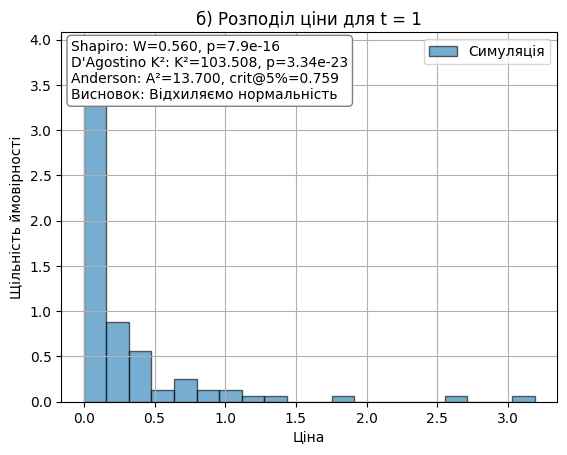

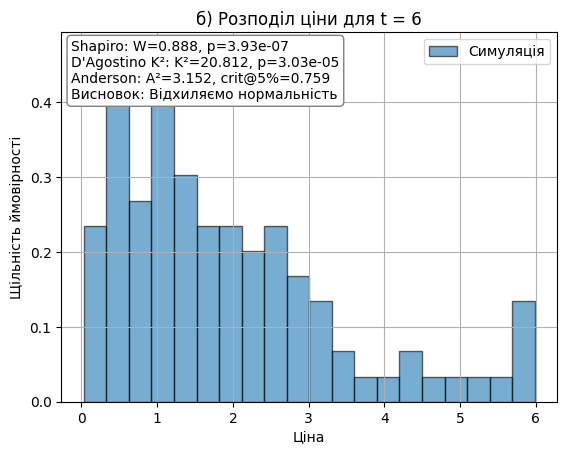

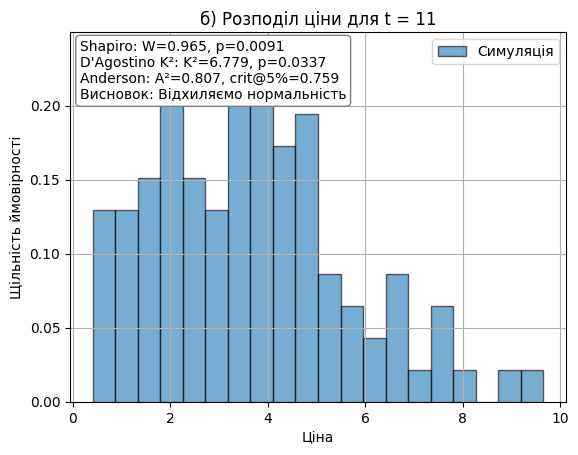

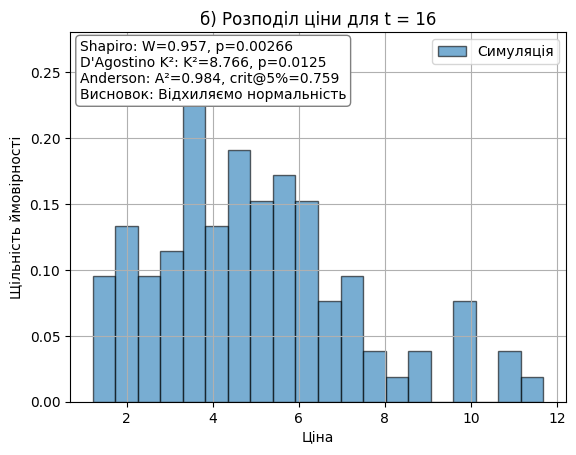

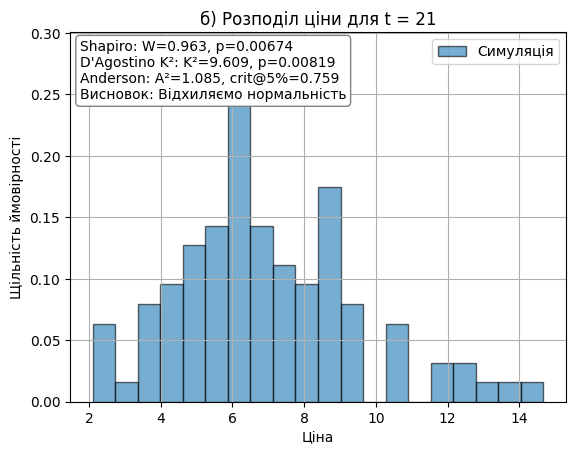

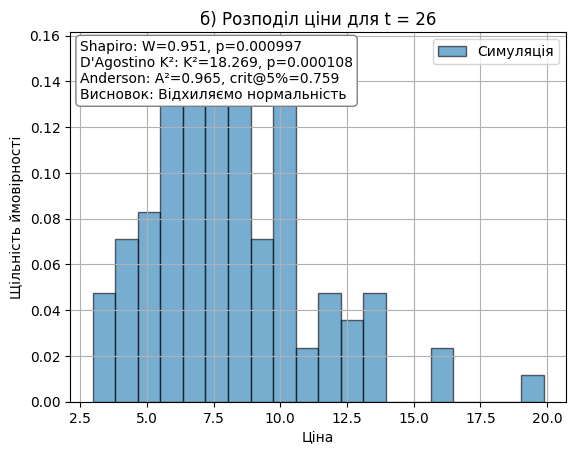

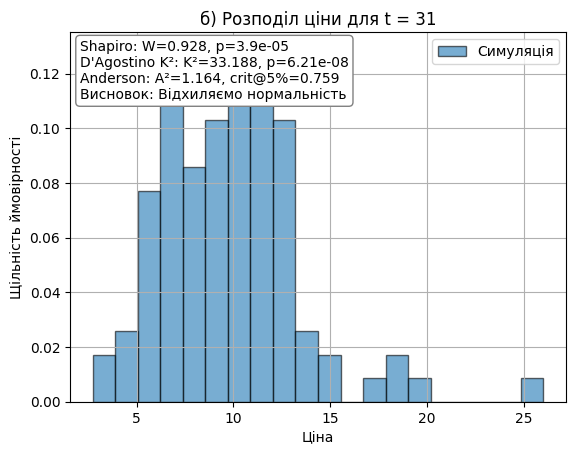

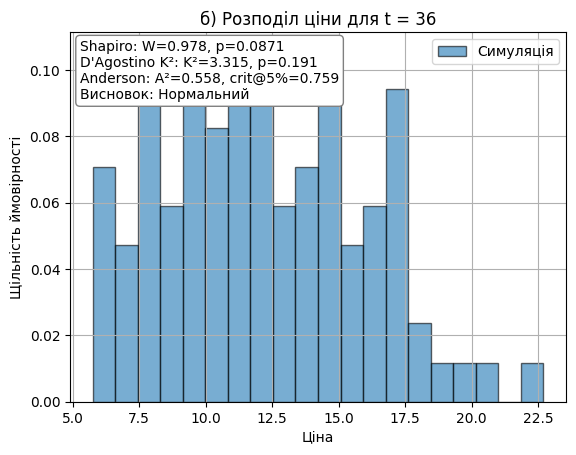

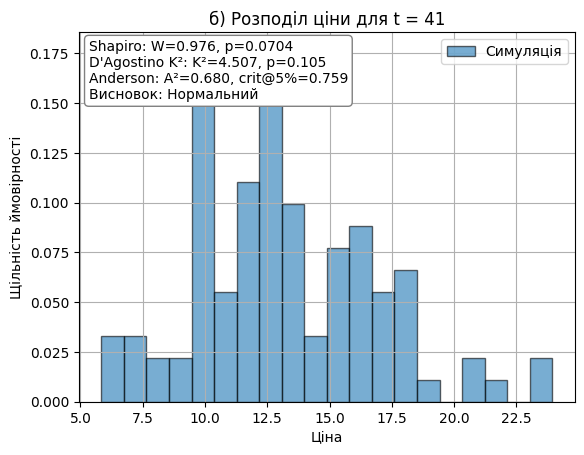

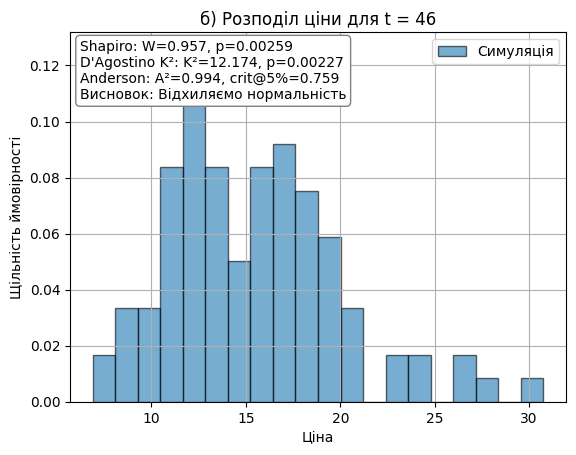

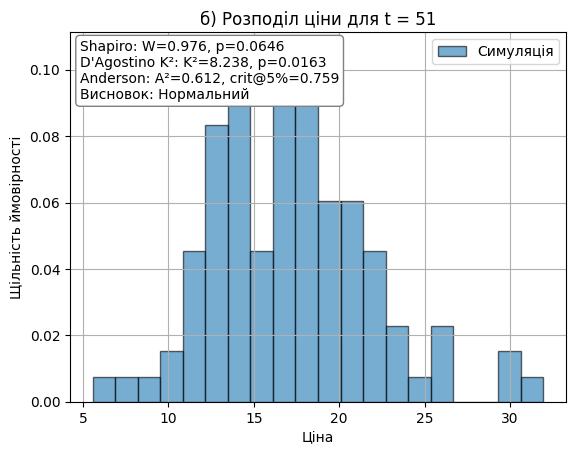

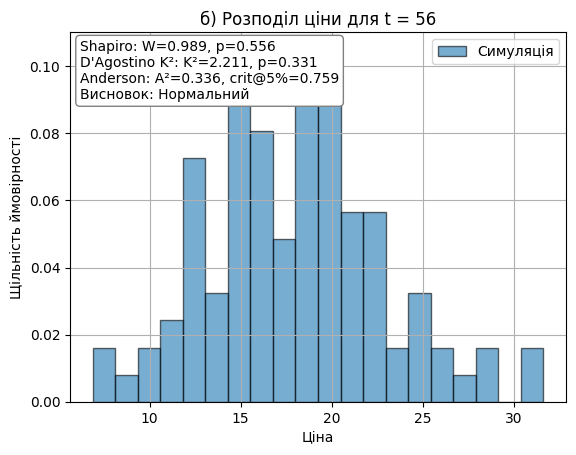

In [7]:
# цикл по t
for t in range(1, 61, 5):
    total_prices = simulate_gamma_sum(t)
    res, is_normal = normality_report(total_prices, alpha=0.05)

    plt.hist(total_prices, bins=20, density=True, alpha=0.6,
             edgecolor='black', label='Симуляція')
    plt.title(f"б) Розподіл ціни для t = {t}")
    plt.xlabel("Ціна")
    plt.ylabel("Щільність ймовірності")
    plt.legend()

    txt = (
        f"Shapiro: W={res['Shapiro'][0]:.3f}, p={res['Shapiro'][1]:.3g}\n"
        f"D'Agostino K²: K²={res['DAgostinoK2'][0]:.3f}, p={res['DAgostinoK2'][1]:.3g}\n"
        f"Anderson: A²={res['Anderson'][0]:.3f}, crit@5%={res['Anderson'][1]:.3f}\n"
        f"Висновок: {'Нормальний' if is_normal else 'Відхиляємо нормальність'}"
    )
    plt.text(0.02, 0.98, txt, transform=plt.gca().transAxes,
             va="top", ha="left",
             bbox=dict(boxstyle="round", fc="white", ec="gray"))
    plt.grid(True)
    plt.show()






### Висновок

- Із зростанням $t$ розподіл суми змін ціни поступово наближається до нормального,  
  що підтверджується результатами тестів Шапіро–Вілка, Д’Агостіно–Пірсона та Андерсона–Дарлінга.

- При малих $t$ розподіл асиметричний (відхиляється від нормальності),  
  але при $t \geq 20{-}30$ більшість тестів дає $p > 0.05$.

- Це узгоджується з центральною граничною теоремою:  
  із зростанням кількості доданків ($t$) розподіл їхньої суми стає близьким до нормального.



### **Завдання 2**

Завантаж набір даних.  
Набір даних складається із семи стовпчиків, що відображають витрати на рекламу на різних платформах — **телебачення**, **білборди**, **Google Ads**, **соціальні медіа**, **інфлюенс-маркетинг** та **партнерський маркетинг**.

Останній стовпчик, `Product_Sold`, містить кількісну оцінку відповідної кількості проданих одиниць товару.  
Для **кожної** колонки порахуй:

- середнє значення,  
- дисперсію,  
- стандартне відхилення,  
- побудуй **гістограму розподілу** показника,  
- перевір на **нормальність розподілу** (Shapiro-Wilk),  
- та порахуй **кореляцію з `Product_Sold`**.


In [ ]:
import pandas as pd
url = 'https://docs.google.com/spreadsheets/d/18WCpPS96Tb3cB0FCsIA92PEhcmBkp08sjYhS9DsQfJE/edit#gid=954244094'
url = url[:url.find('/edit')] + '/export?format=csv'
df = pd.read_csv(url)
df.head()


,TV,Billboards,Google_Ads,Social_Media,Influencer_Marketing,Affiliate_Marketing,Product_Sold
236,981.93,6.37,686.03,398.59,177.39,912.46,7869.0


середнє значення

In [ ]:

df.mean().rename('mean')



,mean
TV,517.431000
Billboards,502.644933
Google_Ads,512.444133
Social_Media,489.800100
Influencer_Marketing,465.732567
Affiliate_Marketing,484.430633
Product_Sold,7031.523333


дисперсія



In [ ]:
df.var().rename('var')

,var
TV,8.301013e+04
Billboards,7.608901e+04
Google_Ads,8.146593e+04
Social_Media,7.501240e+04
Influencer_Marketing,8.312501e+04
Affiliate_Marketing,7.725924e+04
Product_Sold,2.902304e+06


Стандартне відхилення


In [ ]:
df.std().rename('std')

,std
TV,288.114792
Billboards,275.842369
Google_Ads,285.422376
Social_Media,273.883915
Influencer_Marketing,288.314080
Affiliate_Marketing,277.955458
Product_Sold,1703.614951


транспонуємо


In [ ]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
TV,281.42,702.97,313.14,898.52,766.52,507.13,486.64,762.09,638.60,591.48,...,138.83,79.68,594.84,947.72,708.03,770.05,512.38,998.10,322.35,476.45
Billboards,538.80,296.53,295.94,61.27,550.72,612.27,555.02,184.57,778.31,542.51,...,389.62,657.09,79.44,653.82,846.72,501.36,250.83,858.75,681.22,884.77
Google_Ads,123.94,558.13,642.96,548.73,651.91,230.67,203.26,176.61,796.32,400.23,...,804.53,738.08,172.14,879.45,425.30,694.60,373.78,781.06,640.29,301.79
Social_Media,349.30,180.55,505.71,240.93,666.33,142.96,271.62,97.85,759.04,329.15,...,587.20,360.38,622.86,979.08,555.71,172.26,366.95,60.61,343.65,802.30
Influencer_Marketing,242.77,781.06,438.91,278.96,396.33,171.79,70.04,116.67,857.13,577.38,...,436.57,145.03,795.00,304.11,208.48,572.26,987.14,174.63,534.22,434.82
Affiliate_Marketing,910.10,132.43,464.23,432.27,841.93,965.77,366.25,251.74,515.16,931.65,...,95.75,827.38,909.79,92.45,144.39,410.56,509.03,213.53,648.71,401.69
Product_Sold,7164.00,5055.00,6154.00,5480.00,9669.00,7627.00,5177.00,3726.00,9801.00,8652.00,...,5029.00,7617.00,7850.00,8366.00,6814.00,6851.00,6477.00,6949.00,7737.00,8187.00


коротка статистика

In [ ]:
df.describe()

,TV,Billboards,Google_Ads,Social_Media,Influencer_Marketing,Affiliate_Marketing,Product_Sold
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,517.431000,502.644933,512.444133,489.800100,465.732567,484.430633,7031.523333
std,288.114792,275.842369,285.422376,273.883915,288.314080,277.955458,1703.614951
min,1.040000,3.630000,14.860000,11.690000,0.770000,6.740000,2259.000000
25%,273.090000,277.912500,250.530000,265.612500,214.480000,267.677500,5922.500000
50%,513.970000,533.020000,528.965000,486.385000,480.355000,451.315000,7051.000000
75%,774.275000,745.005000,763.345000,695.117500,703.092500,721.065000,8278.000000
max,998.100000,995.320000,999.230000,996.160000,999.830000,987.580000,12227.000000


гістаграма розподілу для всіх стовпів

/tmp/ipython-input-1862355296.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax=ax)


AttributeError: 'Figure' object has no attribute 'tigth_layout'

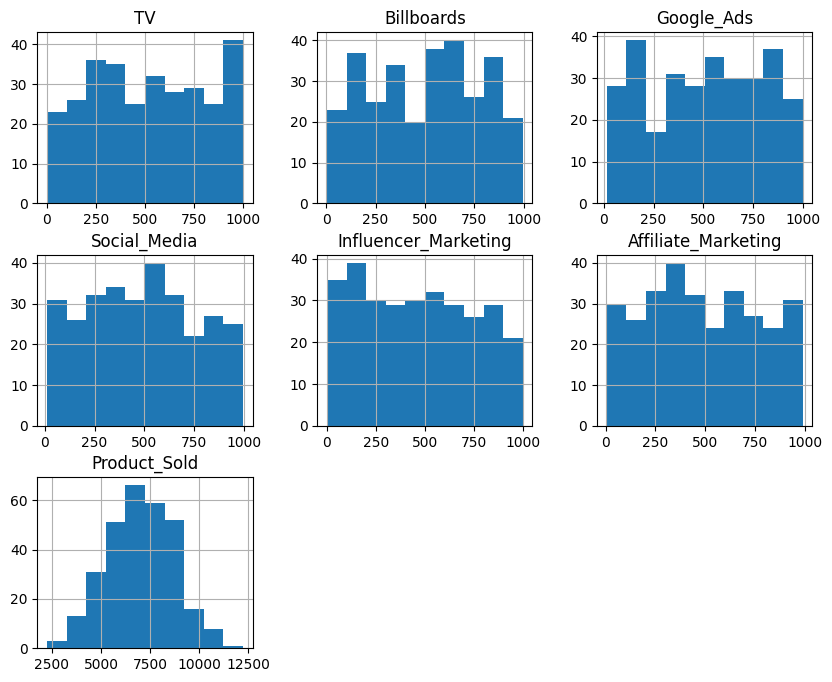

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,8))
df.hist(ax=ax)
fig.tigth_layout()

Кореляція


In [ ]:
df.corr()

,TV,Billboards,Google_Ads,Social_Media,Influencer_Marketing,Affiliate_Marketing,Product_Sold
TV,1.000000,-0.028851,0.025265,-0.038993,0.009970,0.087524,0.374228
Billboards,-0.028851,1.000000,0.052991,0.048722,-0.005815,-0.041060,0.480593
Google_Ads,0.025265,0.052991,1.000000,0.040265,-0.059243,-0.131834,0.203678
Social_Media,-0.038993,0.048722,0.040265,1.000000,-0.042679,-0.019522,0.401088
Influencer_Marketing,0.009970,-0.005815,-0.059243,-0.042679,1.000000,-0.047093,0.140844
Affiliate_Marketing,0.087524,-0.041060,-0.131834,-0.019522,-0.047093,1.000000,0.611603
Product_Sold,0.374228,0.480593,0.203678,0.401088,0.140844,0.611603,1.000000


<Axes: >

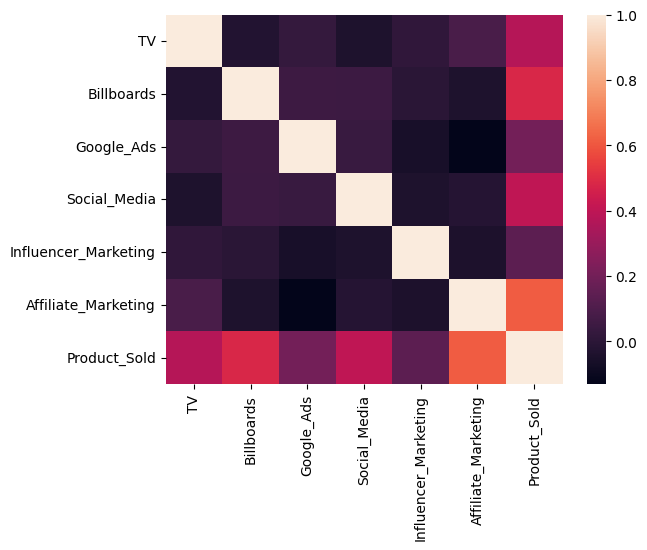

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.corr())

Перевірка на нормальність розподілу

In [ ]:
from scipy.stats import shapiro

for col in df.columns:
    stat, p = shapiro(df[col])
    print(f"{col}: p-value = {p:.4f} {'✓ нормальний' if p > 0.05 else '✗ не є нормальним ймовірним розподілом'}")


TV: p-value = 0.0000 ✗ не є нормальним ймовірним розподілом
Billboards: p-value = 0.0000 ✗ не є нормальним ймовірним розподілом
Google_Ads: p-value = 0.0000 ✗ не є нормальним ймовірним розподілом
Social_Media: p-value = 0.0000 ✗ не є нормальним ймовірним розподілом
Influencer_Marketing: p-value = 0.0000 ✗ не є нормальним ймовірним розподілом
Affiliate_Marketing: p-value = 0.0000 ✗ не є нормальним ймовірним розподілом
Product_Sold: p-value = 0.7863 ✓ нормальний
